In [2]:
import pandas as pd
import numpy as np
import datetime
import warnings
warnings.filterwarnings('ignore')

In [3]:
data_ = pd.read_excel('Flight_Fare.xlsx')
data_.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
data_.shape

(10683, 11)

In [5]:
data_.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [6]:
data_.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [7]:
data_.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,1
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,1
Additional_Info,0


In [8]:
data_.dropna(inplace = True)
data_.isna().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,0
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,0
Additional_Info,0


In [9]:
data_.drop_duplicates(inplace=True)

In [10]:
data = data_.iloc[:,:-1]
y = data_['Price']
print(data.head())
print(y.head())

       Airline Date_of_Journey    Source Destination                  Route  \
0       IndiGo      24/03/2019  Banglore   New Delhi              BLR → DEL   
1    Air India       1/05/2019   Kolkata    Banglore  CCU → IXR → BBI → BLR   
2  Jet Airways       9/06/2019     Delhi      Cochin  DEL → LKO → BOM → COK   
3       IndiGo      12/05/2019   Kolkata    Banglore        CCU → NAG → BLR   
4       IndiGo      01/03/2019  Banglore   New Delhi        BLR → NAG → DEL   

  Dep_Time  Arrival_Time Duration Total_Stops Additional_Info  
0    22:20  01:10 22 Mar   2h 50m    non-stop         No info  
1    05:50         13:15   7h 25m     2 stops         No info  
2    09:25  04:25 10 Jun      19h     2 stops         No info  
3    18:05         23:30   5h 25m      1 stop         No info  
4    16:50         21:35   4h 45m      1 stop         No info  
0     3897
1     7662
2    13882
3     6218
4    13302
Name: Price, dtype: int64


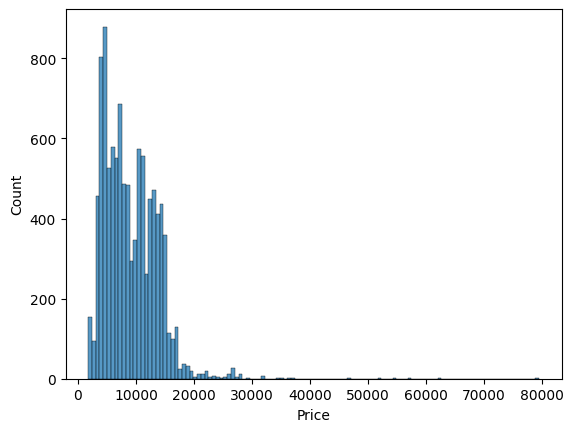

In [11]:
# ploting the price
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(y)
plt.show()

In [15]:
print(data['Airline'].value_counts())
print(data['Destination'].value_counts())
print(data['Source'].value_counts())
print(data['Total_Stops'].value_counts())

Airline
Jet Airways                          3700
IndiGo                               2043
Air India                            1694
Multiple carriers                    1196
SpiceJet                              815
Vistara                               478
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64
Destination
Cochin       4345
Banglore     2860
Delhi        1265
New Delhi     914
Hyderabad     697
Kolkata       381
Name: count, dtype: int64
Source
Delhi       4345
Kolkata     2860
Banglore    2179
Mumbai       697
Chennai      381
Name: count, dtype: int64
Total_Stops
1 stop      5625
non-stop    3475
2 stops     1318
3 stops       43
4 stops        1
Name: count, dtype: int64


In [16]:
data['Date_of_Journey'] = pd.to_datetime(data['Date_of_Journey'],format = '%d/%m/%Y')

In [17]:
data['Jouney_Date'] = data['Date_of_Journey'].dt.day
data['Journey_Month'] = data['Date_of_Journey'].dt.month
data['Journey_Weekday'] = data['Date_of_Journey'].dt.weekday
data.drop(['Date_of_Journey'],axis = 1, inplace = True)
data.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Jouney_Date,Journey_Month,Journey_Weekday
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,24,3,6
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,1,5,2
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,9,6,6
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,12,5,6
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,1,3,4


In [18]:
data.drop(['Route'], axis = 1, inplace = True)

In [19]:
data['Dep_Hour'] = pd.to_datetime(data['Dep_Time']).dt.hour
data['Dep_Min'] = pd.to_datetime(data['Dep_Time']).dt.minute
data.drop(['Dep_Time'], axis = 1, inplace= True)
data.head(5)

,Airline,Source,Destination,Arrival_Time,Duration,Total_Stops,Additional_Info,Jouney_Date,Journey_Month,Journey_Weekday,Dep_Hour,Dep_Min
0,IndiGo,Banglore,New Delhi,01:10 22 Mar,2h 50m,non-stop,No info,24,3,6,22,20
1,Air India,Kolkata,Banglore,13:15,7h 25m,2 stops,No info,1,5,2,5,50
2,Jet Airways,Delhi,Cochin,04:25 10 Jun,19h,2 stops,No info,9,6,6,9,25
3,IndiGo,Kolkata,Banglore,23:30,5h 25m,1 stop,No info,12,5,6,18,5
4,IndiGo,Banglore,New Delhi,21:35,4h 45m,1 stop,No info,1,3,4,16,50


In [20]:
data['Arrival_Hour'] = pd.to_datetime(data['Arrival_Time']).dt.hour
data['Arrival_Min'] = pd.to_datetime(data['Arrival_Time']).dt.minute
data.drop(['Arrival_Time'], axis = 1, inplace= True)
data.head(5)

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Jouney_Date,Journey_Month,Journey_Weekday,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min
0,IndiGo,Banglore,New Delhi,2h 50m,non-stop,No info,24,3,6,22,20,1,10
1,Air India,Kolkata,Banglore,7h 25m,2 stops,No info,1,5,2,5,50,13,15
2,Jet Airways,Delhi,Cochin,19h,2 stops,No info,9,6,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,5h 25m,1 stop,No info,12,5,6,18,5,23,30
4,IndiGo,Banglore,New Delhi,4h 45m,1 stop,No info,1,3,4,16,50,21,35


In [21]:
# Ensure every duration has hours and minutes
data['Duration'] = data['Duration'].apply(lambda x: x if 'h' in x and 'm' in x else
                                      (x + ' 0m' if 'h' in x else '0h ' + x))
data['Duration_hours'] = data['Duration'].apply(lambda x: int(x.split('h')[0]))
data['Duration_mins'] = data['Duration'].apply(lambda x: int(x.split('h')[1].split('m')[0].strip()))
data.drop(["Duration"], axis =1, inplace = True)
data.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Jouney_Date,Journey_Month,Journey_Weekday,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_hours,Duration_mins
0,IndiGo,Banglore,New Delhi,non-stop,No info,24,3,6,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2 stops,No info,1,5,2,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,2 stops,No info,9,6,6,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,1 stop,No info,12,5,6,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,1 stop,No info,1,3,4,16,50,21,35,4,45


In [22]:
# Splitting categorical columns for doing one hot encoding

data_ohe = data.iloc[:,0:5]
data_num = data.iloc[:,5:]
print(data_ohe.head())
print(data_num.head())

       Airline    Source Destination Total_Stops Additional_Info
0       IndiGo  Banglore   New Delhi    non-stop         No info
1    Air India   Kolkata    Banglore     2 stops         No info
2  Jet Airways     Delhi      Cochin     2 stops         No info
3       IndiGo   Kolkata    Banglore      1 stop         No info
4       IndiGo  Banglore   New Delhi      1 stop         No info
   Jouney_Date  Journey_Month  Journey_Weekday  Dep_Hour  Dep_Min  \
0           24              3                6        22       20   
1            1              5                2         5       50   
2            9              6                6         9       25   
3           12              5                6        18        5   
4            1              3                4        16       50   

   Arrival_Hour  Arrival_Min  Duration_hours  Duration_mins  
0             1           10               2             50  
1            13           15               7             25  
2        

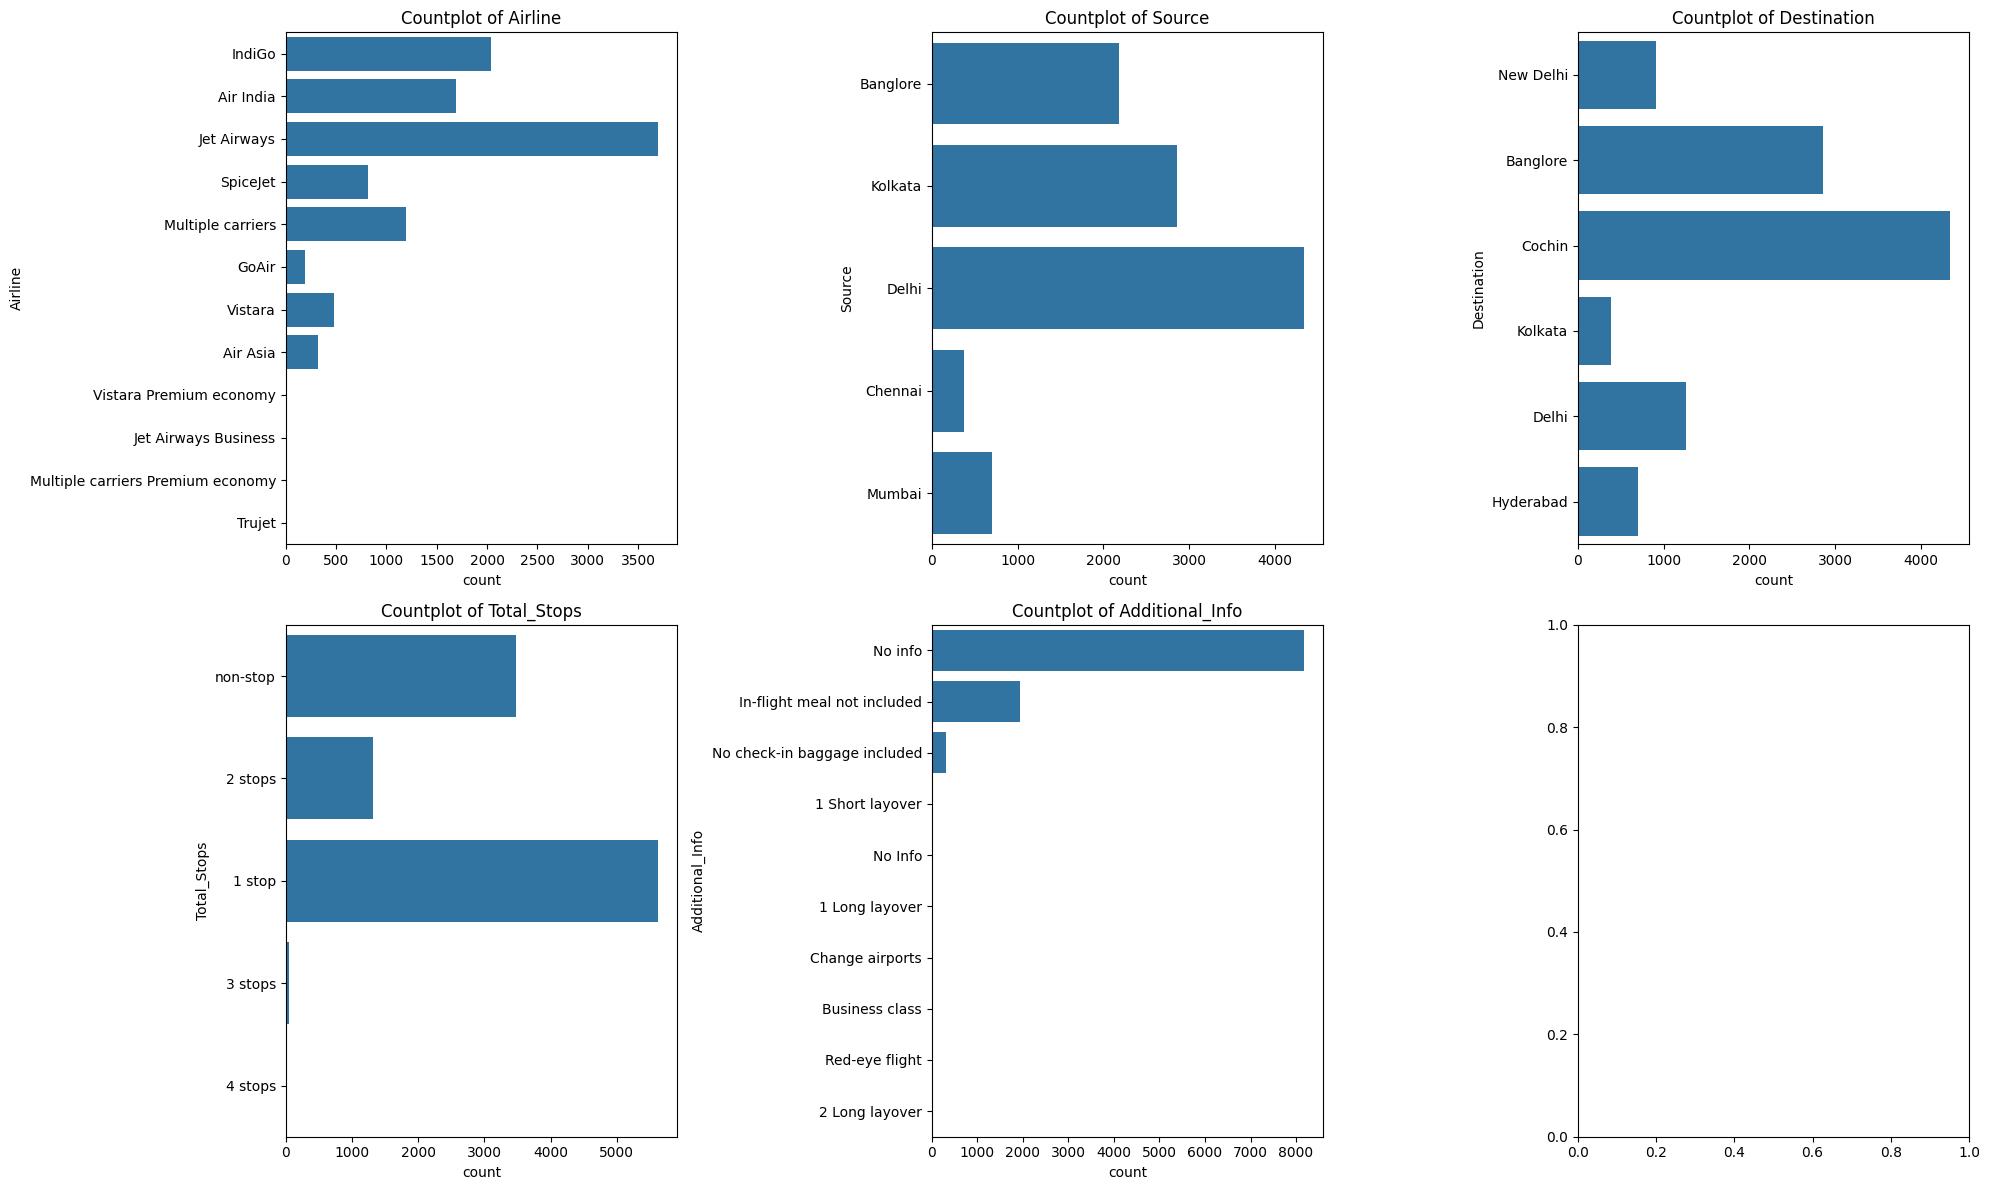

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(2,3,figsize = (20,12))
axes = axes.flatten()

for i,col in enumerate(data_ohe.columns):
  sns.countplot(data_ohe[col],ax = axes[i])
  axes[i].set_title(f'Countplot of {col}')
  #plt.title('')
  #plt.xlabel('Number of Flights')
  #plt.ylabel('Name of the Airlines')
  plt.tight_layout()
plt.show()


In [24]:
data_ohe['Additional_Info'].value_counts()

,count
Additional_Info,
No info,8182
In-flight meal not included,1926
No check-in baggage included,318
1 Long layover,19
Change airports,7
Business class,4
No Info,3
1 Short layover,1
Red-eye flight,1


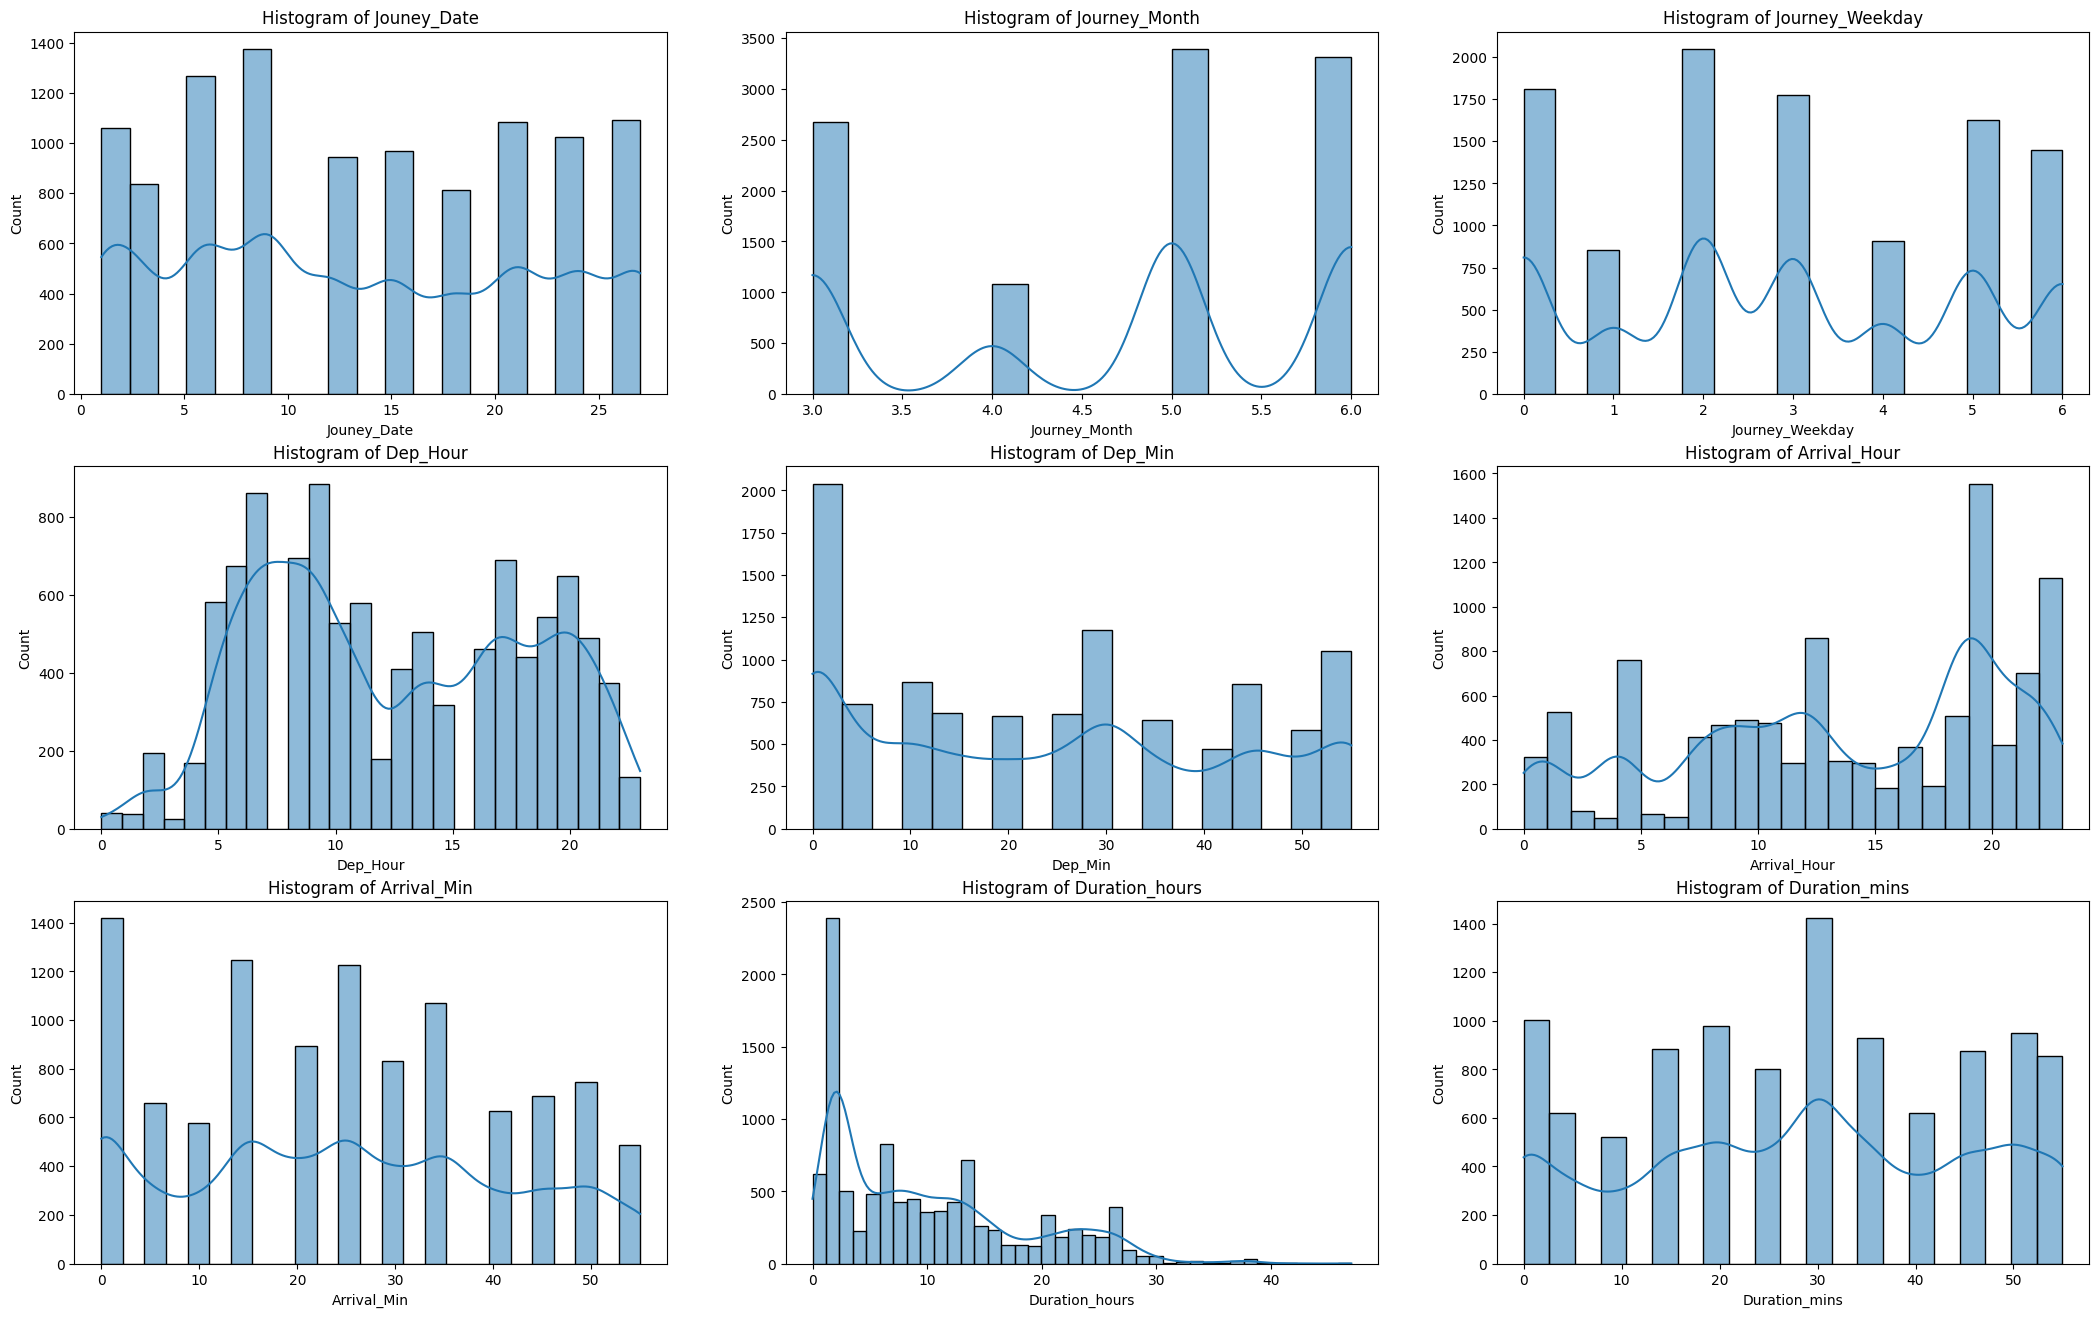

In [25]:
# visualizing the numerical data
fig, axes = plt.subplots(3, 3, figsize=(26,16))
axes = axes.flatten()
for i, col in enumerate(data_num.columns):
    sns.histplot(data_num[col], ax=axes[i], kde=True)
    axes[i].set_title(f'Histogram of {col}')
plt.show()


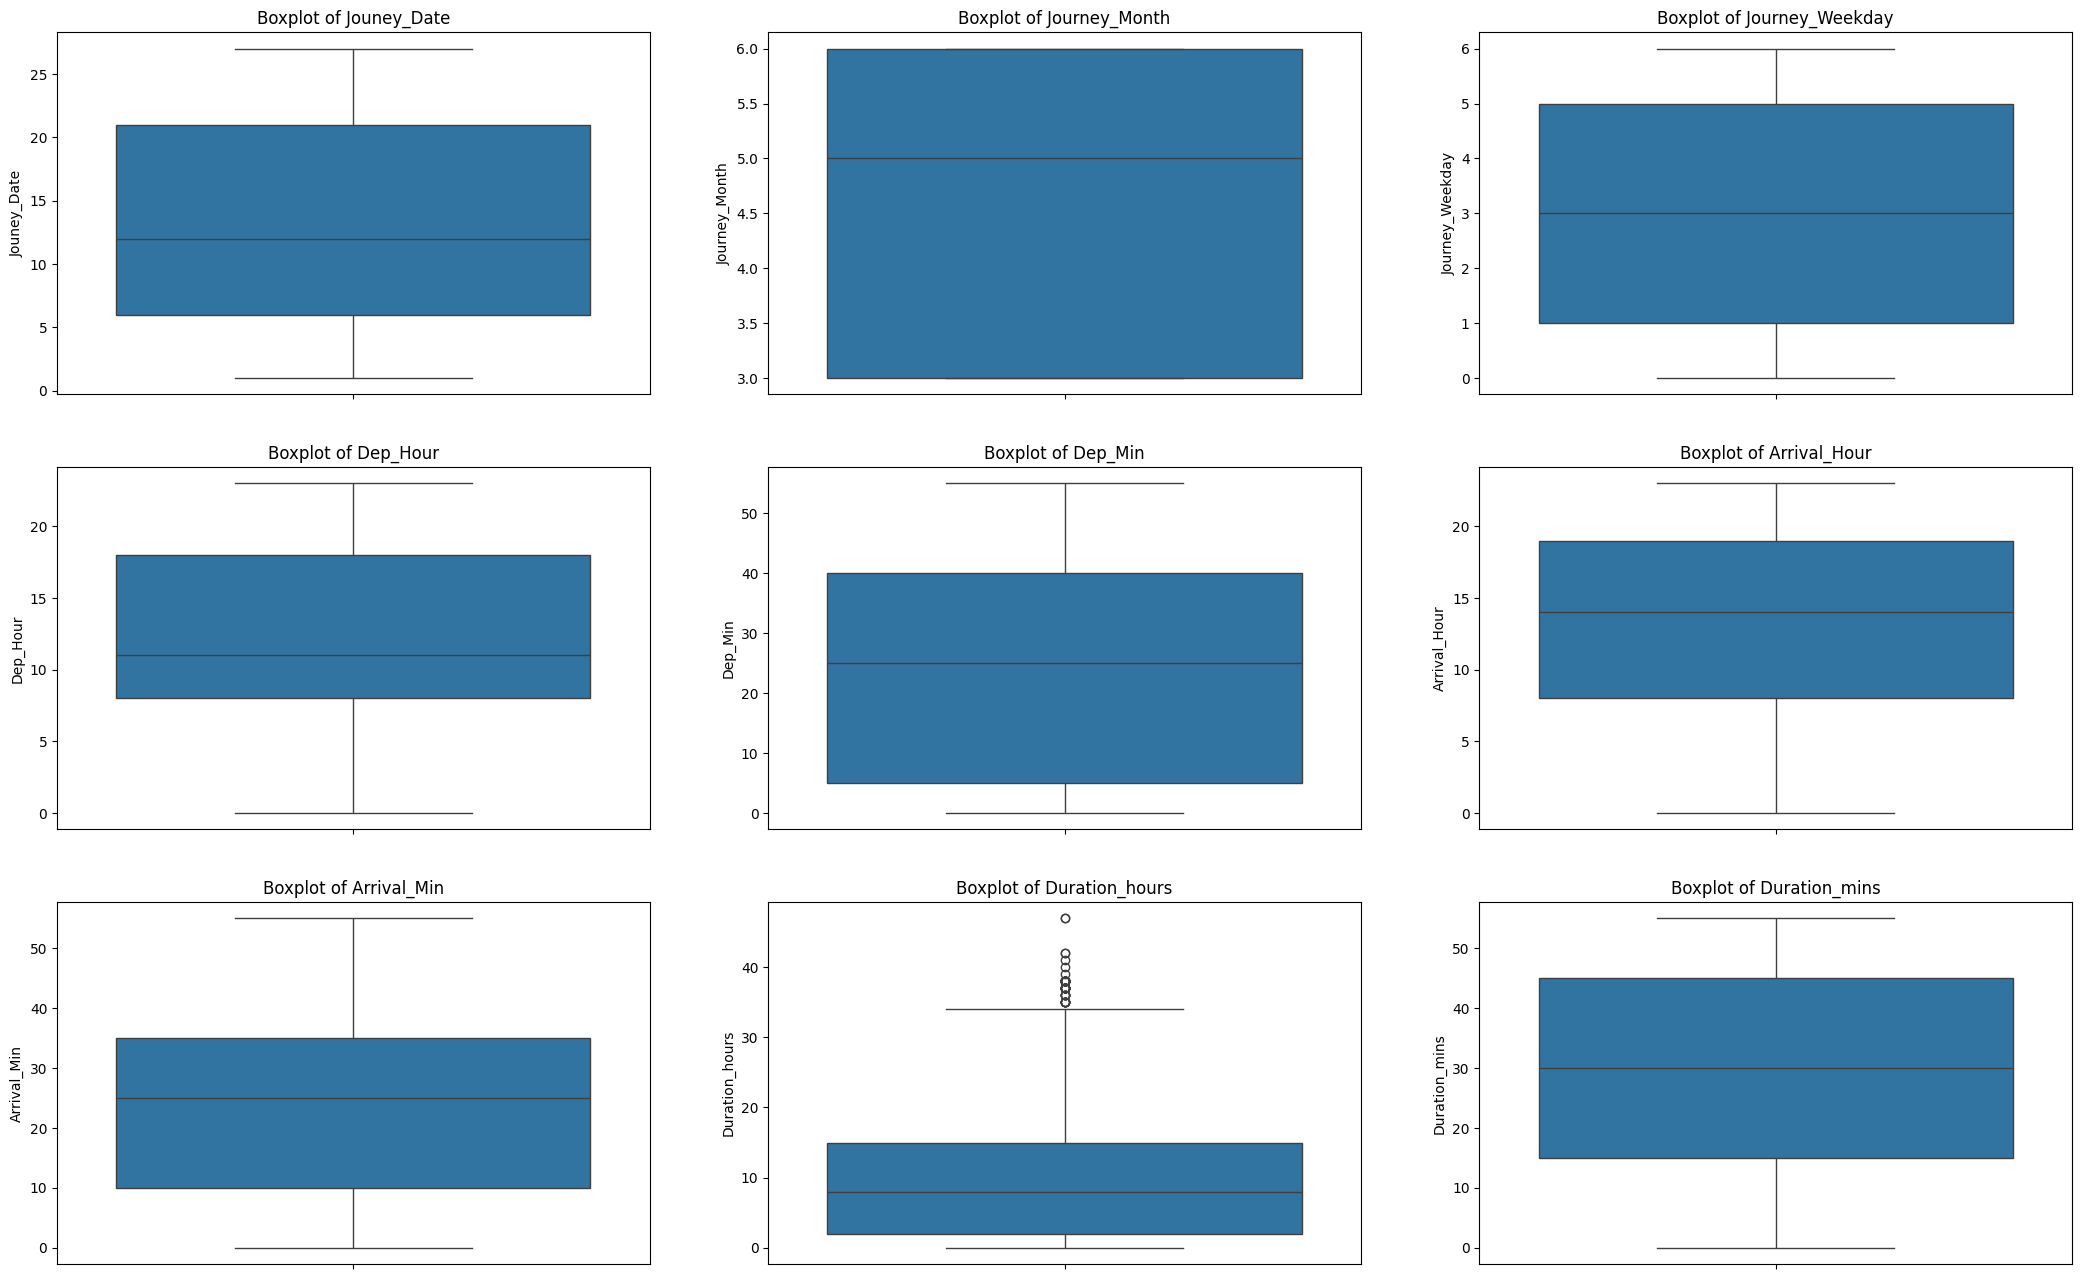

In [26]:
# Outliers check
fig, axes = plt.subplots(3, 3, figsize=(26,16))
axes = axes.flatten()
for i, col in enumerate(data_num.columns):
    sns.boxplot(data_num[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
plt.show()

In [27]:
# From above plot it is visible that only Duration hour feature has outliers.

In [28]:

# Remove Outlier
Q1 = data_num['Duration_hours'].quantile(0.25)
Q3 = data_num['Duration_hours'].quantile(0.75)

IQR = Q3-Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

data_num_of = data_num[(data_num['Duration_hours'] >= lower_bound) & (data_num['Duration_hours']<= upper_bound)]
outliers = data_num[(data_num['Duration_hours'] <= lower_bound) | (data_num['Duration_hours']>= upper_bound)]
data_num_of

# there is

,Jouney_Date,Journey_Month,Journey_Weekday,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_hours,Duration_mins
0,24,3,6,22,20,1,10,2,50
1,1,5,2,5,50,13,15,7,25
2,9,6,6,9,25,4,25,19,0
3,12,5,6,18,5,23,30,5,25
4,1,3,4,16,50,21,35,4,45
...,...,...,...,...,...,...,...,...,...
10678,9,4,1,19,55,22,25,2,30
10679,27,4,5,20,45,23,20,2,35
10680,27,4,5,8,20,11,20,3,0
10681,1,3,4,11,30,14,10,2,40


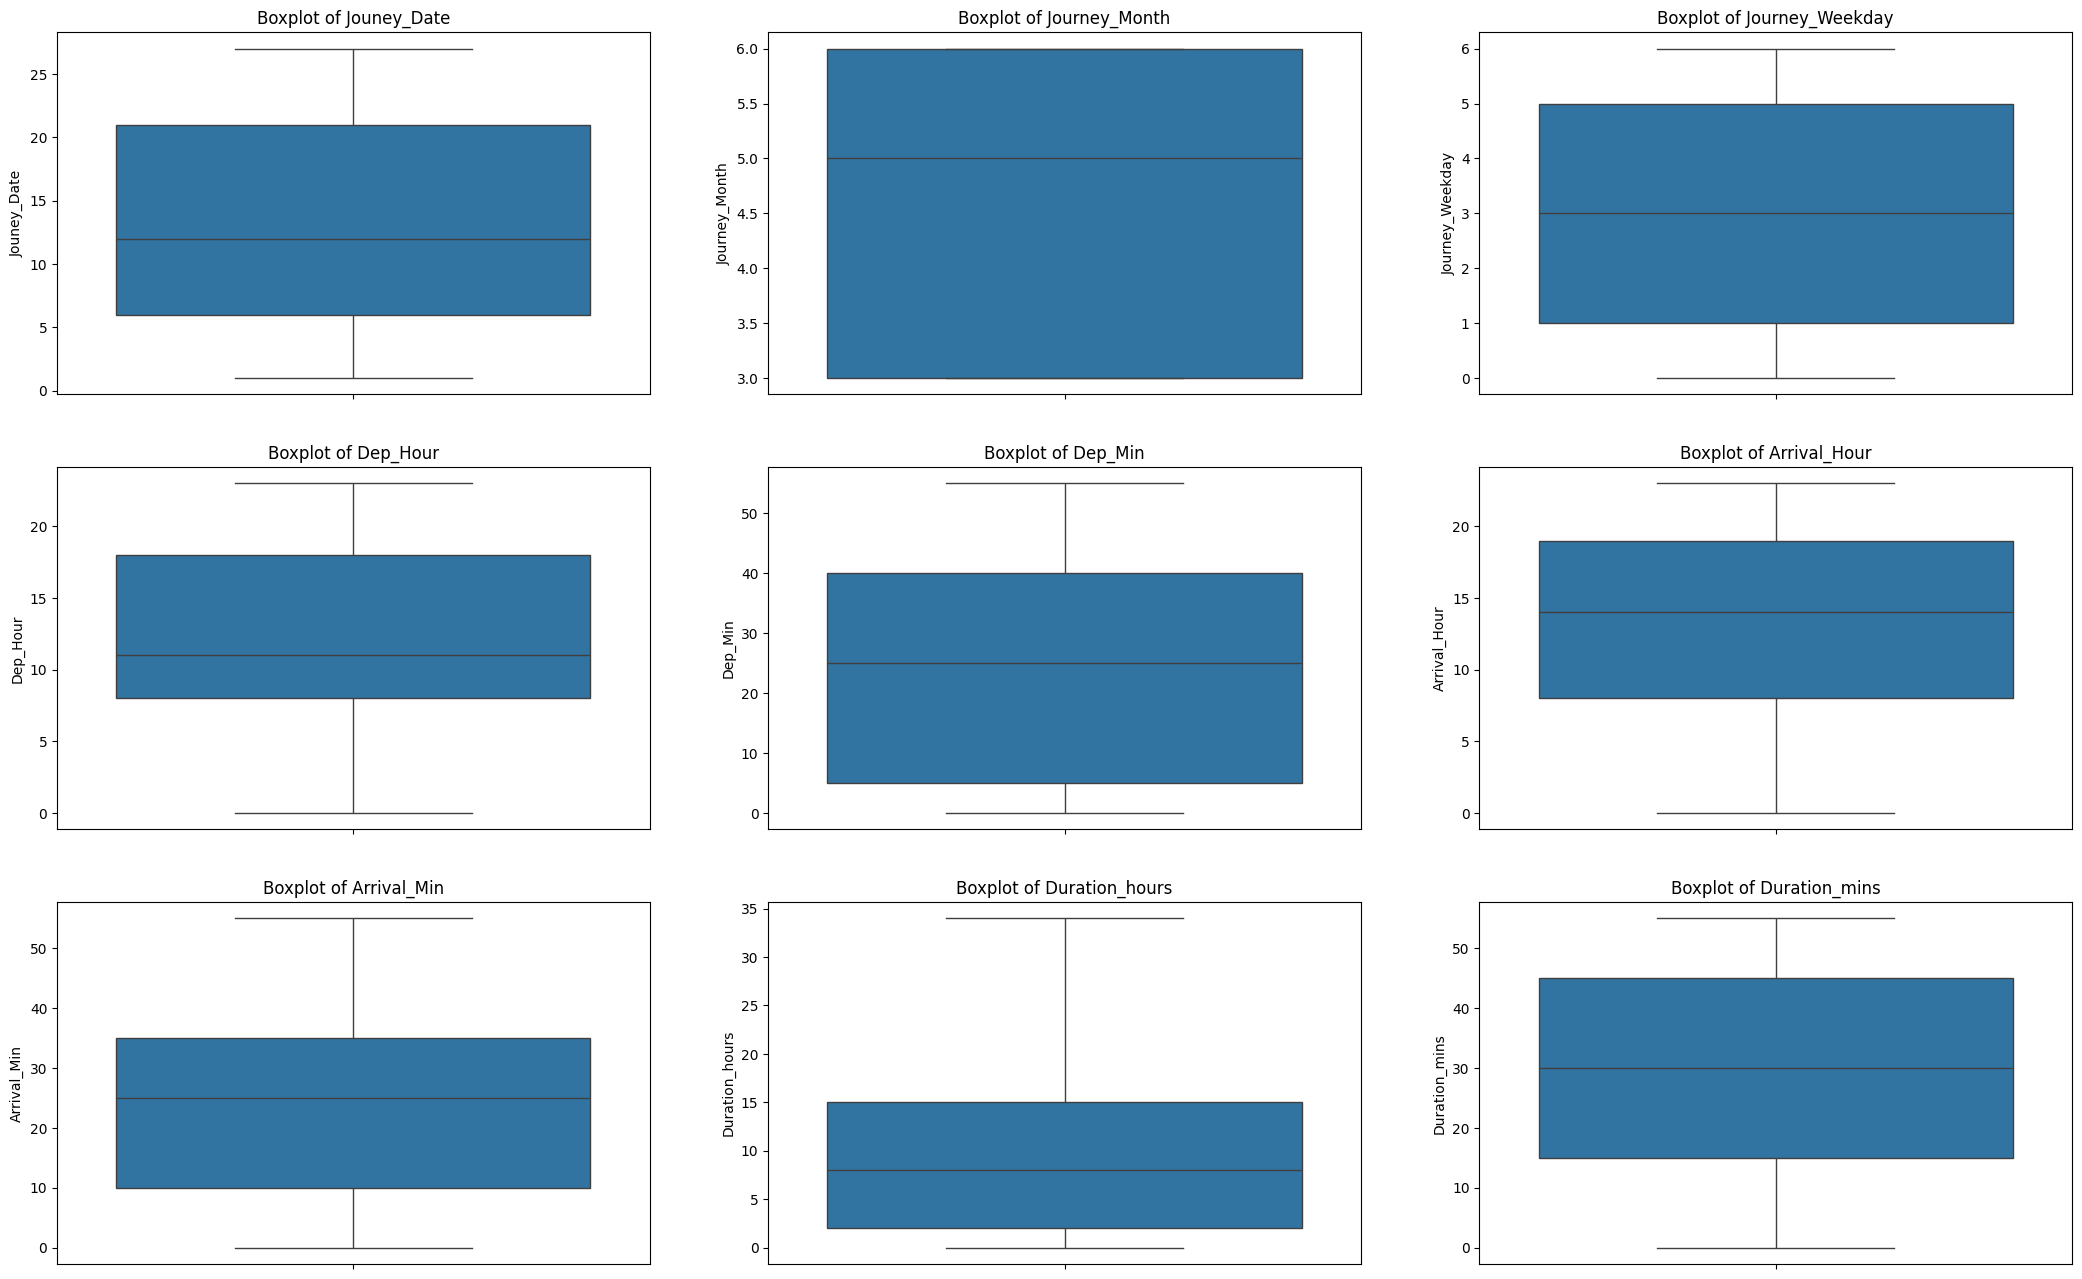

In [29]:
# Plots after removing outliers
fig, axes = plt.subplots(3, 3, figsize=(26,16))
axes = axes.flatten()
for i, col in enumerate(data_num_of.columns):
    sns.boxplot(data_num_of[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
plt.show()


In [30]:
# Skewness check

for i, col in enumerate(data_num_of.columns):
  skew_values = data_num_of[col].skew()
  print(skew_values)
# There is not much skewness in data. In duration_hours there is skewness but it's distribution is like exponential distribution.

0.12326323427110479
-0.385837402439077
0.04125366064011779
0.09946603758831293
0.16884611766435131
-0.37062295317903793
0.10703768718520539
0.7964214293915333
-0.09250432780806969


In [31]:
# There is not much skewness in any of the numerical columns.

In [32]:
'''# Removing skewness from the Duration_Hours column
data_num_of['Duration_hours'] = np.log1p(data_num_of['Duration_hours'])

fig, axes = plt.subplots(3, 3, figsize=(26,16))
axes = axes.flatten()
for i, col in enumerate(data_num_of.columns):
    sns.histplot(data_num_of[col], ax=axes[i], kde=True)
    axes[i].set_title(f'Histogram of {col}')
plt.show()'''

"# Removing skewness from the Duration_Hours column\ndata_num_of['Duration_hours'] = np.log1p(data_num_of['Duration_hours'])\n\nfig, axes = plt.subplots(3, 3, figsize=(26,16))\naxes = axes.flatten()\nfor i, col in enumerate(data_num_of.columns):\n    sns.histplot(data_num_of[col], ax=axes[i], kde=True)\n    axes[i].set_title(f'Histogram of {col}')\nplt.show()"

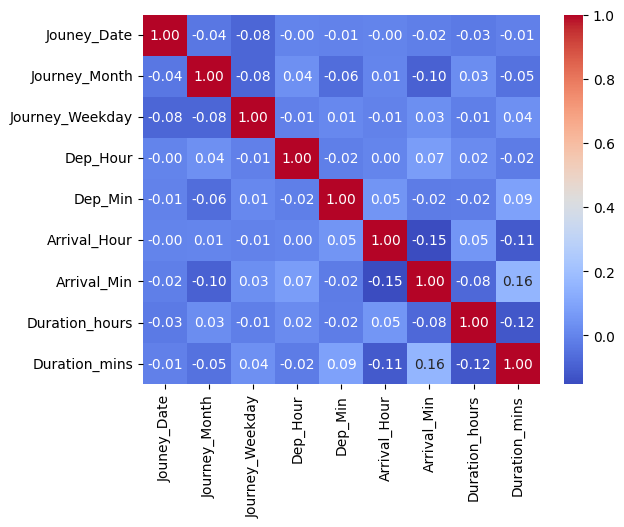

In [33]:
# Checking correlation between features using heatmap

sns.heatmap(data_num_of.corr(), cmap='coolwarm',annot = True, fmt= '.2f')
plt.show() #

# Features are not correlated much.

In [34]:
# One hot encoding
data_ohe = pd.get_dummies(data_ohe, drop_first= True)
data_ohe = data_ohe.astype(int)
data_ohe.head()

,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,...,Total_Stops_non-stop,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No Info,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight
0,0,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [35]:
# Concating the one hot encoded columns and other columns

data_concat = pd.concat([data_num_of, y], axis = 1)

# Scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data_concat)
scaled_data = pd.DataFrame(scaled_data, columns = data_concat.columns)
scaled_data.head()

,Jouney_Date,Journey_Month,Journey_Weekday,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_hours,Duration_mins,Price
0,0.884615,0.000000,1.000000,0.956522,0.363636,0.043478,0.181818,0.058824,0.909091,0.027497
1,0.000000,0.666667,0.333333,0.217391,0.909091,0.565217,0.272727,0.205882,0.454545,0.075920
2,0.307692,1.000000,1.000000,0.391304,0.454545,0.173913,0.454545,0.558824,0.000000,0.155917
3,0.423077,0.666667,1.000000,0.782609,0.090909,1.000000,0.545455,0.147059,0.454545,0.057348
4,0.000000,0.000000,0.666667,0.695652,0.909091,0.913043,0.636364,0.117647,0.818182,0.148457


In [36]:
data_concat_2 = pd.concat([scaled_data, data_ohe], axis = 1)
data_concat_2.head(5)

,Jouney_Date,Journey_Month,Journey_Weekday,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_hours,Duration_mins,Price,...,Total_Stops_non-stop,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No Info,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight
0,0.884615,0.000000,1.000000,0.956522,0.363636,0.043478,0.181818,0.058824,0.909091,0.027497,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.000000,0.666667,0.333333,0.217391,0.909091,0.565217,0.272727,0.205882,0.454545,0.075920,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.307692,1.000000,1.000000,0.391304,0.454545,0.173913,0.454545,0.558824,0.000000,0.155917,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.423077,0.666667,1.000000,0.782609,0.090909,1.000000,0.545455,0.147059,0.454545,0.057348,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.000000,0.000000,0.666667,0.695652,0.909091,0.913043,0.636364,0.117647,0.818182,0.148457,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [37]:
data_concat_2.isnull().sum()
data_concat_2 = data_concat_2.dropna()

In [38]:
data_concat_2.isnull().sum()

,0
Jouney_Date,0
Journey_Month,0
Journey_Weekday,0
Dep_Hour,0
Dep_Min,0
Arrival_Hour,0
Arrival_Min,0
Duration_hours,0
Duration_mins,0
Price,0


In [40]:
Y = data_concat_2['Price']
data_concat_2.drop(['Price'], axis = 1)
X = data_concat_2

In [41]:
# Train test split
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
X_train, X_test, y_train, y_test = train_test_split(X, Y, random_state=42)

In [42]:
# MOdel Building
# Linear Models
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [43]:
y_pred_lr = lr.predict(X_test)
mse_lr = mean_squared_error(y_test,y_pred_lr)
print(mse_lr)

6.238017089126724e-32


In [44]:
r2_score_lr = r2_score(y_test,y_pred_lr)
r2_score_lr

1.0

In [45]:
# Model - Lasso
las = Lasso()
las.fit(X_train,y_train)

Lasso()

In [46]:
y_pred_las = las.predict(X_test)
mse_las = mean_squared_error(y_test,y_pred_las)
print(mse_las)

0.0034777942973566846


In [47]:
r2_score_las = r2_score(y_test,y_pred_las)
r2_score_las

-7.608604724040902e-08

In [48]:
# Model - Ridge
ridg = Ridge()
ridg.fit(X_train, y_train)

Ridge()

In [49]:
y_pred_ridg = ridg.predict(X_test)
mse_ridg = mean_squared_error(y_test,y_pred_ridg)
print(mse_ridg)

5.8057016443462e-06


In [50]:
r2_score_ridg = r2_score(y_test,y_pred_ridg)
r2_score_ridg

0.9983306367226803

In [51]:
# Elasticnet
elas = ElasticNet()
elas.fit(X_train,y_train)

ElasticNet()

In [52]:
y_pred_elas = elas.predict(X_test)
mse_elas = mean_squared_error(y_test,y_pred_elas)
mse_elas

0.0034777942973566846

In [53]:
r2_score_elas = r2_score(y_test,y_pred_elas)
r2_score_elas # Prediction is worse than mean prediction

-7.608604724040902e-08

In [54]:
# SVM Regression

from sklearn.svm import SVR
svr = SVR()
svr.fit(X_train, y_train)
svr_pred = svr.predict(X_test)
mse_svr = mean_squared_error(y_test,svr_pred)
mse_svr


0.0024627062068555876

In [55]:
svr_r2_score = r2_score(y_test, svr_pred)
svr_r2_score

0.2918769243756132

In [56]:
# SVM with hyperparameter tuning

from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf','poly','sigmoid'],
    'gamma': ['scale', 'auto']
}
grid_search = GridSearchCV(estimator=svr, param_grid=param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)
best_params_svr_cv = grid_search.best_params_
print("Best Hyperparameters:", best_params_svr_cv)

Best Hyperparameters: {'C': 10, 'gamma': 'auto', 'kernel': 'sigmoid'}


In [57]:
svm_reg = SVR(C=10, gamma='auto', kernel='sigmoid')
svm_reg.fit(X_train, y_train)
y_pred_svr_cv = svm_reg.predict(X_test)
mse_svr_cv = mean_squared_error(y_test,y_pred_svr_cv)
mse_svr_cv

0.002027787177283668

In [58]:
svr_cv_r2_score = r2_score(y_test, y_pred_svr_cv)
svr_cv_r2_score

0.41693292984257024

In [59]:
# Decision tree
from sklearn.tree import DecisionTreeRegressor
decision_tree_reg = DecisionTreeRegressor()
decision_tree_reg.fit(X_train,y_train)
y_pred_dt = decision_tree_reg.predict(X_test)
mse_dt = mean_squared_error(y_test, y_pred_dt)
mse_dt

6.168254490955928e-06

In [60]:
dt_r2_score = r2_score(y_test, y_pred_dt)
dt_r2_score

0.9982263887875823

In [61]:
#Deecision tree hyperparameter tuning
# Decision tree with hyperparameter tuning
from sklearn.model_selection import GridSearchCV
params = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [1,2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2'],
}
grid_search = GridSearchCV(estimator=decision_tree_reg, param_grid=params, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)
best_params_dt_cv = grid_search.best_params_
print("Best Hyperparameters:", best_params_dt_cv)


Best Hyperparameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5}


In [62]:
dt_reg_cv = DecisionTreeRegressor(max_depth=30, max_features='sqrt', min_samples_leaf=2, min_samples_split=2,random_state = 42)
dt_reg_cv.fit(X_train, y_train)
y_pred_dtr_cv = dt_reg_cv.predict(X_test)
mse_dtr = mean_squared_error(y_test, y_pred_dtr_cv)
mse_dtr

0.00068804265271297

In [63]:
dt_r2_score = r2_score(y_test,y_pred_dtr_cv)
dt_r2_score

0.8021611842924792

In [64]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)
mse_rf = mean_squared_error(y_test,y_pred_dt)
mse_rf

6.168254490955928e-06

In [65]:
rf_r2_score = r2_score(y_test,y_pred_rf)
rf_r2_score

0.9993922014643767

In [66]:
# Random forest regressor with hyperparameter tuning
param_grid = {
    'n_estimators': [25,50,75,100],
    'max_depth': [None, 10,15,20,25],
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf': [1, 2, 3, 4],
    'max_features': ['log2', 'sqrt','None']
}
grid_search = GridSearchCV(estimator=rf_reg, param_grid=param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)
best_params_rfreg_cv = grid_search.best_params_
print("Best Hyperparameters:", best_params_rfreg_cv)

Best Hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [67]:
rf_reg_cv = RandomForestRegressor(n_estimators=100, max_depth = None,max_features='sqrt', min_samples_leaf=1, min_samples_split = 2, random_state=42)
rf_reg_cv.fit(X_train, y_train)
y_pred_rf_cv = rf_reg_cv.predict(X_test)
mse_rf_cv = mean_squared_error(y_test, y_pred_rf_cv)
mse_rf_cv

0.00023003813087361984

In [68]:
rf_cv_r2_score = r2_score(y_test,y_pred_rf_cv)
rf_cv_r2_score

0.9338551597053473

In [69]:
# XGBoost
from xgboost import XGBRegressor
xgb_reg = XGBRegressor(random_state = 42)
xgb_reg.fit(X_train, y_train)
xgb_reg_pred = xgb_reg.predict(X_test)
mse_xgb = mean_squared_error(y_test,xgb_reg_pred)
mse_xgb

7.019927140243283e-05

In [70]:
r2_score_xgb = r2_score(y_test,xgb_reg_pred)
r2_score_xgb

0.9798150003302457

In [71]:
# XGB Regressor with hyperparameter tuning

param_grid ={
    'n_estimators': [75,100,125,130],
    'max_depth': [None, 10,15,20,25],
    'learning_rate': [ 0.2, 0.3, 0.4, 0.5],
    'gamma': [0, 0.1, 0.2, 0.3]
}

In [72]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(estimator = xgb_reg, param_grid = param_grid, scoring='r2', cv = 5)
grid_search.fit(X_train, y_train)
best_params_xgb_cv = grid_search.best_params_
print("Best Hyperparameters:", best_params_xgb_cv)

Best Hyperparameters: {'gamma': 0, 'learning_rate': 0.3, 'max_depth': None, 'n_estimators': 75}


In [73]:
xgb_reg_cv = XGBRegressor(n_estimators=75, max_depth=None, learning_rate=0.3, gamma=0, random_state=42)
xgb_reg_cv.fit(X_train,y_train)
xgb_reg_cv_predict = xgb_reg_cv.predict(X_test)
mse_xgb_cv = mean_squared_error(y_test, xgb_reg_cv_predict)
mse_xgb_cv

7.019927158396538e-05

In [74]:
r2_score_xgb_cv = r2_score(y_test,xgb_reg_cv_predict)
r2_score_xgb_cv

0.9798150002780481

In [ ]:
# Final observation.
# Except Support Vector Regressor all other models are performing well.
# Decision tree performance is good with default parameters.